In [ ]:
# Assignment3: song profiling
# Given the information collected in the previous assignment,
# build some song categories based on the lyrics or/and the melodic information available in the data.
# For this assignment, you can use any software/package you want!

In [1]:
import pandas as pd
df = pd.read_csv("df_track_clean.csv") 

In [ ]:
#Text Cleaning, trasform raw text into a clean and structured format.

In [6]:
! pip install spacy


   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
   --- ------------------------------------ 1.3/14.2 MB 7.9 MB/s eta 0:00:02
   -------- ------------------------------- 2.9/14.2 MB 7.9 MB/s eta 0:00:02
   ------------ --------------------------- 4.5/14.2 MB 7.9 MB/s eta 0:00:02
   ------------------ --------------------- 6.6/14.2 MB 8.1 MB/s eta 0:00:01
   ---------------------- ----------------- 8.1/14.2 MB 8.2 MB/s eta 0:00:01
   ---------------------------- ----------- 10.0/14.2 MB 8.3 MB/s eta 0:00:01
   --------------------------------- ------ 11.8/14.2 MB 8.3 MB/s eta 0:00:01
   -------------------------------------- - 13.6/14.2 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------- 14.2/14.2 MB 8.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/653.1 kB ? eta -:--:--
   ---------------------------------------- 653.1/653.1 kB 6.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ----------

In [21]:
! python -m spacy download en_core_web_sm


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     --- ------------------------------------ 1.0/12.8 MB 6.8 MB/s eta 0:00:02
     ------- -------------------------------- 2.4/12.8 MB 6.5 MB/s eta 0:00:02
     ------------ --------------------------- 3.9/12.8 MB 6.7 MB/s eta 0:00:02
     ---------------- ----------------------- 5.2/12.8 MB 6.8 MB/s eta 0:00:02
     --------------------- ------------------ 6.8/12.8 MB 6.8 MB/s eta 0:00:01
     ------------------------- -------------- 8.1/12.8 MB 6.8 MB/s eta 0:00:01
     ----------------------------- ---------- 9.4/12.8 MB 6.8 MB/s eta 0:00:01
     --------------------------------- ------ 10.7/12.8 MB 6.7 MB/s eta 0:00:01
     ------------------------------------- -- 12.1/12.8 MB 6.6 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 6.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [8]:
! pip install contractions



   ---------- ----------------------------- 1/4 [anyascii]
   ---------- ----------------------------- 1/4 [anyascii]
   ---------- ----------------------------- 1/4 [anyascii]
   ---------- ----------------------------- 1/4 [anyascii]
   ---------- ----------------------------- 1/4 [anyascii]
   ---------- ----------------------------- 1/4 [anyascii]
   ---------------------------------------- 4/4 [contractions]



In [9]:
import re
import warnings
warnings.filterwarnings("ignore")

import pandas as pd

import re
from collections import Counter
from typing import Iterable, Optional, Set, List
import warnings

from nltk.corpus import stopwords as nltk_stopwords
import spacy
from spacy.language import Language
from spacy.tokens import Doc
import contractions

import nltk
nltk.download('stopwords')

RANDOM_STATE = 42

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
df.columns

Index(['id', 'id_artist', 'title', 'featured_artists', 'primary_artist',
       'album', 'swear_IT', 'swear_EN', 'year', 'month', 'day', 'n_sentences',
       'n_tokens', 'char_per_tok', 'avg_token_per_clause', 'bpm', 'rolloff',
       'flux', 'rms', 'flatness', 'spectral_complexity', 'pitch', 'album_name',
       'album_release_date', 'album_type', 'disc_number', 'track_number',
       'duration_ms', 'explicit', 'popularity', 'id_album', 'streams@1month',
       'swear_IT_words_clean', 'swear_EN_words_clean', 'lyrics_clean',
       'season', 'language_group'],
      dtype='object')

In [17]:
# ---------------------------------------------------------
# 0. Text Normalization Configurations
# ---------------------------------------------------------

CURLY_MAP = {
    "’": "'",
    "‘": "'",
    "“": '"',
    "”": '"',
    "—": "-",
    "–": "-",
    "…": "...",
}

SECTION_LINE_RE = re.compile(r"^\s*\[.*?\]\s*$", re.IGNORECASE)
BRACKET_SECTION_RE = re.compile(r"\[.*?\]")
HYPHEN_REPEAT_RE = re.compile(r"\b(\w{1,3})(?:-\1)+\b", re.IGNORECASE)

LYRICS_FILLER_WORDS = {
    "yeah", "yea", "yay",
    "whoo", "woo", "whoa", "woah",
    "oh", "ooh", "ah", "uh", "mm", "mmm", "hm", "hmm",
    "la", "na", "da",
    "hey", "yo",
    "ow", "aw", "ew",
    "oh-oh", "oh-oh-oh",
    "la-la", "la-la-la",
    "na-na", "na-na-na",
    "uh-huh", "mm-hmm", "uh-uh",
}

italian_contractions = {
    "l'": "lo ",
    "un'": "una ",
    "dell'": "della ",
    "all'": "alla ",
    "nell'": "nella ",
    "sull'": "sulla ",
    "com'è": "come è",
    " dov'è": "dove è",
    " dov’": "dove ",   
}

# ---------------------------------------------------------
# 1. Basic Text Normalization
# ---------------------------------------------------------

def normalize_unicode_quotes(text: str) -> str:
    if text is None or not isinstance(text, str):
        return ""
    for bad, good in CURLY_MAP.items():
        text = text.replace(bad, good)
    return text

def normalize_repetitions(text: str) -> str:
    return HYPHEN_REPEAT_RE.sub(r"\1", text)

def remove_parenthetical_adlibs(text: str, max_length: int) -> str:
    return re.sub(r"\([^)]{0," + str(max_length) + r"}\)", " ", text)

def expand_italian_contractions(text: str) -> str:
    if text is None or not isinstance(text, str):
        return ""
    new_text = text
    for contr, full in italian_contractions.items():
        new_text = new_text.replace(contr, full)
    return new_text

def expand_contractions(text: str, language: str = "en") -> str:
    if text is None or not isinstance(text, str):
        return ""
    try:
        if language == "en":
            import contractions
            return contractions.fix(text)
        elif language == "it":
            return expand_italian_contractions(text)
        else:
            return text
    except Exception:
        return text

def remove_chorus_tag(text: str) -> str:
    """Rimuove linee che contengono solo [Chorus], [Verse], [Bridge] ecc."""
    if text is None or not isinstance(text, str):
        return ""
    lines = text.split("\n")
    cleaned_lines = [line for line in lines if not SECTION_LINE_RE.match(line)]
    return "\n".join(cleaned_lines)

def basic_pre_normalization(text: str, language: str = "en") -> str:
    if text is None or not isinstance(text, str):
        return ""

    text = text.strip().strip('"').strip("'")
    if not text:
        return ""

    text = normalize_unicode_quotes(text)
    text = expand_contractions(text, language=language)
    text = text.lower()
    text = normalize_repetitions(text)
    text = remove_parenthetical_adlibs(text, max_length=15)
    text = BRACKET_SECTION_RE.sub(" ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

# ---------------------------------------------------------
# 2. spaCy NLP pipeline
# ---------------------------------------------------------

def create_nlp(model: str = "en_core_web_sm") -> Language:
    import spacy
    nlp = spacy.load(model, disable=("ner", "textcat"))
    return nlp

def build_stopword_set(nlp: Language, use_nltk_or_spacy: bool = True,
                       extra_stopwords: Optional[Iterable[str]] = None,
                       keep_words: Optional[Iterable[str]] = None) -> Set[str]:
    import nltk
    from nltk.corpus import stopwords as nltk_stopwords
    nltk.download('stopwords', quiet=True)

    if use_nltk_or_spacy:
        stops = set(nltk_stopwords.words('english'))
    else:
        stops = set(nlp.Defaults.stop_words)

    if extra_stopwords:
        stops.update(extra_stopwords)
    if keep_words:
        stops.difference_update(keep_words)
    return stops

# ---------------------------------------------------------
# 3. Token-level cleaning
# ---------------------------------------------------------

def compress_token_runs(tokens: List[str], max_run: int = 1) -> List[str]:
    if not tokens:
        return tokens
    compressed = []
    prev = None
    count = 0
    for tok in tokens:
        if tok == prev:
            count += 1
        else:
            prev = tok
            count = 1
        if count <= max_run:
            compressed.append(tok)
    return compressed

def detokenize_sentences(sentences: List[List[str]]) -> str:
    if not sentences:
        return ""
    flat_tokens = [tok for sent in sentences for tok in sent]
    return " ".join(flat_tokens)

# ---------------------------------------------------------
# 4. Full cleaning function
# ---------------------------------------------------------

def clean_text(text: str, nlp: Language, stopwords: Optional[Set[str]] = None,
               language: str = "en") -> str:
    if text is None or not isinstance(text, str):
        return ""

    text = basic_pre_normalization(text, language=language)
    text = remove_chorus_tag(text)
    if not text.strip():
        return ""

    try:
        doc = nlp(text)
    except Exception:
        return ""

    sentences: List[List[str]] = []

    for sent in doc.sents:
        sent_tokens: List[str] = []
        for token in sent:
            if token.is_space or token.is_punct:
                continue
            form = token.lemma_.strip().lower()
            if not form or form in {"'", '"', "-", "_", "..."}:
                continue
            if stopwords and form in stopwords:
                continue
            sent_tokens.append(form)
        sent_tokens = compress_token_runs(sent_tokens)
        if sent_tokens:
            sentences.append(sent_tokens)

    cleaned = detokenize_sentences(sentences)
    return cleaned



In [22]:
# ---------------------------------------------------------
# 5. V1: Clean all lyrics in the dataset
# ---------------------------------------------------------

def clean_all_lyrics_v1(texts: Iterable[str], nlp: Language, stopwords: Optional[Set[str]] = None) -> List[str]:
    """
    Apply the full cleaning pipeline to an iterable of lyrics texts (df["track_lyrics"])
    This is a simple wrapper around "clean_text" that iterates over all rows and returns a list of cleaned strings
    """
    texts_list = list(texts)
    cleaned = [clean_text(text, nlp=nlp, stopwords=stopwords) for text in texts_list]
    print("✅ V1 lyrics cleaning completed")
    return cleaned

In [23]:
nlp = create_nlp()
stops = build_stopword_set(nlp, use_nltk_or_spacy=True)

# V1: Clean all lyrics in the dataset
df["track_lyrics_clean"] = clean_all_lyrics_v1(df["lyrics_clean"], nlp=nlp, stopwords=stops)

✅ V1 lyrics cleaning completed


In [ ]:
#10 minutes to clean 14k lyrics

#An example before cleaning
#Oplà, ah Bdope, chiama due b— Mi candiderei come presidente Nascevo in America, ero Franco West (Ah-ah) Rosa è il sesso come un ditalino Questa si fa il tipo mentre pensa a me (Ah-ah) Tutto duro come un palo (La) Chiede a cosa penso mentre chiavo (La) Penso a Pupo con due fiche in mano (La) Sono così fiero di essere italiano (Uh) Esce il tuo singolo e ronf (Ronf) Sei la strada, the real Tom (Tom) Dice che vuole il ragazzo sporco (Ah) La sbatto col cazzo che sa di tonno (Ah) Pesto merda, penso: "Vedi? (Ecco) Anche oggi un nemico tra i piedi" (Che cazzo) Entro in ufficio coi debiti Esco e non so come spenderli (Tu-tu) Fanculo Marco Mengo**, fuck (Fuck) Mi sta sui coglioni la scena rap (Sulla minchia) A saperlo prima di fare trap (Ah) Restavo in cantina a fumare cra** Il-Il più politically scorretto (Yeah) Le ho lasciato minchia sopra il rossetto (Proprio io) Che asciugo che mi fai sentire il pezzo (Che palle) Nel prossimo zitto che suona meglio Ah, shazammo mentre sto cagando Esce l'ultimo pezzo di — (Dai) Anche quest'anno è il tuo anno, bravo (Bravo) Aspetta che parte l'applauso (Bravissimo) Più italiano dell'Italia stessa (L'Italia) Più ceco di Russia, Slovacchia e Cechia (Shlet) Fossi un falegname con moglie (Shlet) Lo stesso mi fotte una se** (Yeh-ah) Sono duro come se mi chiamassi Yuri o Nicolaj (Pre, Nicolaj), na zdrowie (Pre-pre-pre) Con quella faccia da schiaffi dove vai? (Dove vai?) Bevo la vodka (Ehi), ballo la polka (Ehi) Bevo la vodka, guardami, ballo la polka (Ehi) Bevo la vodka, guardami, ballo la polka (Ballo la polka) Bevo la vodka, guardami, ballo la polka (Yeh, yeh) Bevo la vodka, guardami, ballo la polka (Tu-tu-ru-tu) Mhm, guarda che porca (Mhm) Bacio mami, che guapa (Muah) Baciamani a Guè Papa (Ah-ah) Vuole che l'apra da pa' (Uh-uh-uh) Arrivo in gola alla iatro Come un oto-laringoiatra (Splash) PSG, Paris Saint Germain PSC, pippotto sul ca' (Uoh) Stai con un cesso che fa selfie al cesso (Ah) Ti suonerei come un synth, uh Passion fru', ai rapper piscio in cu' E, frate', sono un hustler come Larry Flynt (Yeah) Cocainum come Danko (Ah) Stendo, stando, spendo e spando (Ah) A 'sti babbi di minchia tolgo le catene alla Django King of the jungle Da quanto schifo fai Spotify mi dovrebbe un bel risarcimento (Seh-seh) Scappo che ho finito il tempo Ho un importantissimo apputtanamento (Ahah) Siete dei peluches, io sono Jim Belushi (Ah) Lei miss Bielorussia cola miele in pussy (Mhm) Per la gafi resto in zona rosa sempre (Seh) Per i soldi passo in zona verde, bitch (Seh) La sua figa sa del mio cazzo Frate', come il vino quando sa di tappo La pussy non la vedi manco Fra', un pelo se è tanto, come i porno giappo' (Ahahah) Fanno i fighi solo coi compari (Sì) Perché in branco stanno solo i cani (Sì) "Quanto scopa Ernia" sopra la Treccani Sta sotto la voce "proverbi italiani" Non andavo a scuola, ma alla nave scuola È lì che io mi divertivo Il tuo disco, Dio mio che fastidio Mi chiedo perché tu non abbia un sussidio (Ahahahahah) Cambio in ogni pezzo, che impressione Sembra che c'ho dentro due persone Lei è fan di ogni mia canzone Le dedico "Acqua Calda Col Ciddone" Roba da manette, due tette perfette Capezzoli duri, pistacchio di Bronte Chiederò ai rapper come ci si sente Ad avere per sempre questo cazzo in fronte (Seh) Ora divertitevi voi stronzi Quando torno poi facciamo i conti Ti tappo la bocca con quei finti soldi Stai fermo a guardare perché mi cuckoldi (Stronzo) Sono duro come se mi chiamassi Yuri o Nicolaj (Pre, Nicolaj), na zdrowie (Pre-pre-pre) Con quella faccia da schiaffi dove vai? (Dove vai?) Bevo la vodka (Ehi), ballo la polka (Ehi) Bevo la vodka, guardami, ballo la polka (Ehi) Bevo la vodka, guardami, ballo la polka (Ballo la polka) Bevo la vodka, guardami, ballo la polka (Yeh, yeh) Bevo la vodka, guardami, ballo la polka (Tu-tu-ru-tu)


#an example after cleaning
# oplà ah bdope chiama due b- mi candiderei come presidente nascevo america ero franco west rosa è il sesso come un ditalino questa si fa il tipo mentre pensa tutto duro come un palo chiede cosa penso mentre chiavo penso pupo con due fiche mano sono così fiero di essere italiano esce il tuo singolo e ronf sei la strada real tom dice che vuole il ragazzo sporco la sbatto col cazzo che sa di tonno pesto merda penso vedi anche oggi un nemico tra piedi entro ufficio coi debiti esco e non come spenderli fanculo marco mengo fuck mi sta sui coglioni la scena rap saperlo prima di fare trap restavo cantina fumare cra il più politically scorretto le ho lasciato minchia sopra il rossetto che asciugo che mi fai sentire il pezzo nel prossimo zitto che suona meglio ah shazammo mentre sto cagando esce l'ultimo pezzo di anche quest'anno è il tuo anno bravo aspetta che parte l'applauso più italiano dell'italia stessa più ceco di russia slovacchia e cechia fossi un falegname con moglie lo stesso mi fotte una se sono duro come se mi chiamassi yuri nicolaj na zdrowie con quella faccia da schiaffi dove vai bevo la vodka ballo la polka bevo la vodka guardami ballo la polka bevo la vodka guardami ballo la polka bevo la vodka guardami ballo la polka bevo la vodka guardami ballo la polka mhm guarda che porca bacio mami che guapa baciamani guè papa vuole che l'apra da pa arrivo gola alla iatro come un oto laringoiatra psg paris saint germain psc pippotto sul stai con un cesso che fa selfie al cesso ti suonerei come un synth uh passion fru ai rapper piscio cu e frate sono un hustler come larry flynt cocainum come danko stendo stando spendo e spando sti babbi di minchia tolgo le catene alla django king jungle da quanto schifo fai spotify mi dovrebbe un bel risarcimento scappo che ho finito il tempo ho un importantissimo apputtanamento siete dei peluche io sono jim belushi lei miss bielorussia cola miele pussy per la gafi resto zona rosa sempre per soldi passo zona verde bitch la sua figa sa del mio cazzo frate come il vino quando sa di tappo la pussy non la vedi manco fra un pelo se è tanto come porno giappo fanno fighi solo coi compari perché branco stanno solo cani quanto scopa ernia sopra la treccani sta sotto la voce proverbi italiani non andavo scuola alla nave scuola è lì che io mi divertivo il tuo disco dio mio che fastidio mi chiedo perché tu non abbia un sussidio cambio ogni pezzo che impressione sembra che c'ho dentro due persone lei è fan di ogni mia canzone le dedico acqua calda col ciddone roba da manette due tette perfette capezzoli duri pistacchio di bronte chiederò ai rapper come ci si sente ad avere per sempre questo cazzo fronte ora divertitevi voi stronzi quando torno poi facciamo conti ti tappo la bocca con quei finti soldi stai fermo guardare perché mi cuckoldi sono duro come se mi chiamassi yuri nicolaj na zdrowie con quella faccia da schiaffi dove vai bevo la vodka ballo la polka bevo la vodka guardami ballo la polka bevo la vodka guardami ballo la polka bevo la vodka guardami ballo la polka bevo la vodka guardami ballo la polka

In [26]:
# simple tokenization
docs = [text.split() for text in df['track_lyrics_clean'].dropna()]


In [28]:
! pip install gensim

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   - -------------------------------------- 1.0/24.4 MB 8.6 MB/s eta 0:00:03
   ---- ----------------------------------- 2.9/24.4 MB 7.9 MB/s eta 0:00:03
   ------- -------------------------------- 4.5/24.4 MB 7.8 MB/s eta 0:00:03
   --------- ------------------------------ 6.0/24.4 MB 7.8 MB/s eta 0:00:03
   ------------ --------------------------- 7.6/24.4 MB 7.8 MB/s eta 0:00:03
   --------------- ------------------------ 9.2/24.4 MB 7.7 MB/s eta 0:00:02
   ----------------- ---------------------- 10.7/24.4 MB 7.6 MB/s eta 0:00:02
   -------------------- ------------------- 12.3/24.4 MB 7.6 MB/s eta 0:00:02
   ---------------------- ----------------- 13.9/24.4 MB 7.6 MB/s eta 0:00:02
   ------------------------- -------------- 15.7/24.4 MB 7.7 MB/s eta 0:00:02
   ---------------------------- ----------- 17.3/24.4 MB 7.7 MB/s eta 0:00:01
   ------------------------------ --------- 18.9/24.4 MB 7.7 MB/s eta 0:00:01


In [29]:
import gensim
from gensim import corpora

# Dizionary
dictionary = corpora.Dictionary(docs)

# remove too rare or too common words
dictionary.filter_extremes(no_below=5, no_above=0.5)

# Crea la matrice Bag-of-Words
corpus = [dictionary.doc2bow(doc) for doc in docs]


In [30]:
from gensim.models import LdaModel

#number of topics to discover (to be chosen based on the dataset)
num_topics = 7

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=10,         # quante volte il modello vede tutti i documenti
    alpha='auto',      # distribuzione prior dei topic
    per_word_topics=True
)


In [31]:
# explore the topics
for i, topic in lda_model.show_topics(formatted=True, num_topics=num_topics, num_words=10):
    print(f"Topic {i}: {topic}")


Topic 0: 0.009*"fra" + 0.008*"faccio" + 0.007*"cazzo" + 0.006*"rap" + 0.006*"sto" + 0.006*"tutti" + 0.006*"tipo" + 0.005*"del" + 0.005*"su" + 0.005*"fa"
Topic 1: 0.012*"tutto" + 0.011*"mai" + 0.009*"sempre" + 0.009*"siamo" + 0.008*"anche" + 0.007*"perché" + 0.007*"sai" + 0.007*"ora" + 0.007*"noi" + 0.007*"senza"
Topic 2: 0.008*"chi" + 0.007*"gli" + 0.006*"del" + 0.006*"ha" + 0.006*"nel" + 0.006*"c'è" + 0.006*"della" + 0.005*"vita" + 0.005*"nella" + 0.005*"senza"
Topic 3: 0.013*"soldi" + 0.012*"yeah" + 0.012*"ah" + 0.011*"ehi" + 0.010*"sto" + 0.010*"lei" + 0.009*"bitch" + 0.007*"nel" + 0.007*"gang" + 0.007*"baby"
Topic 4: 0.012*"chi" + 0.012*"questo" + 0.012*"mondo" + 0.010*"marcio" + 0.009*"ogni" + 0.009*"ha" + 0.008*"perché" + 0.007*"uomo" + 0.007*"c'è" + 0.006*"questa"
Topic 5: 0.015*"oh" + 0.010*"sì" + 0.010*"po" + 0.010*"bene" + 0.009*"voglio" + 0.009*"sto" + 0.009*"fare" + 0.009*"eh" + 0.009*"perché" + 0.008*"cosa"
Topic 6: 0.024*"nun" + 0.014*"na" + 0.012*"pe" + 0.011*"de" + 0.01

In [32]:
#assign topics to documents
# topic distribution for each document
topic_distributions = [lda_model.get_document_topics(bow) for bow in corpus]

# optional: extract dominant topic
dominant_topics = [max(dist, key=lambda x: x[1])[0] if dist else None for dist in topic_distributions]

# add to DataFrame
df['lyric_category'] = dominant_topics


In [ ]:
# how many songs belong to each topic
topic_counts = df['lyric_category'].value_counts().sort_index()
print(topic_counts)


lyric_category
0    3237
1    2832
2    1444
3     687
4    1115
5     892
6     554
Name: count, dtype: int64


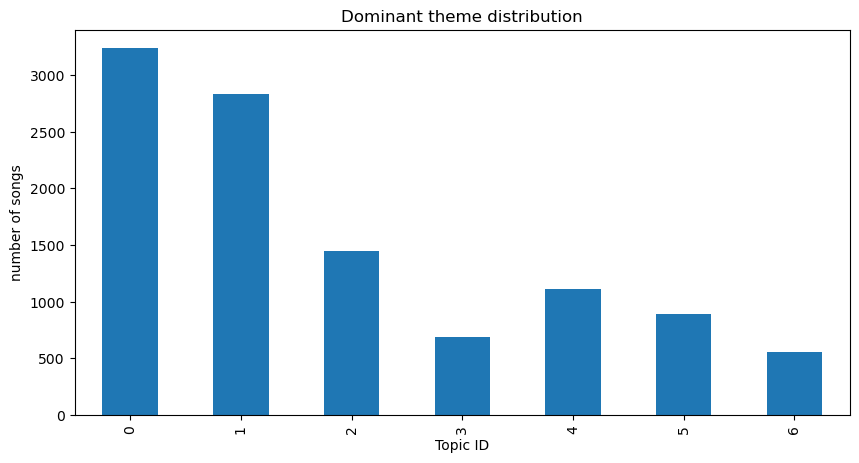

In [36]:
import matplotlib.pyplot as plt

topic_counts.plot(kind='bar', figsize=(10,5))
plt.xlabel("Topic ID")
plt.ylabel("number of songs")
plt.title("Dominant theme distribution")
plt.show()

In [38]:
num_words_per_topic = []

for i, topic in lda_model.show_topics(num_topics=num_topics, formatted=False):
    num_words_per_topic.append((i, len(topic)))  # topic_id, number of words

for topic_id, n_words in num_words_per_topic:
    print(f"Topic {topic_id}: {n_words} words")


Topic 0: 10 words
Topic 1: 10 words
Topic 2: 10 words
Topic 3: 10 words
Topic 4: 10 words
Topic 5: 10 words
Topic 6: 10 words


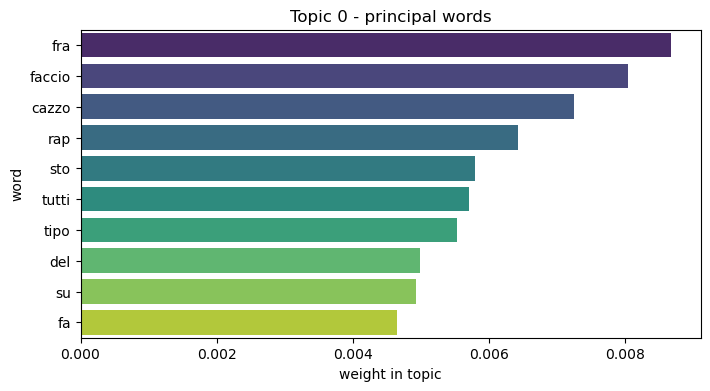

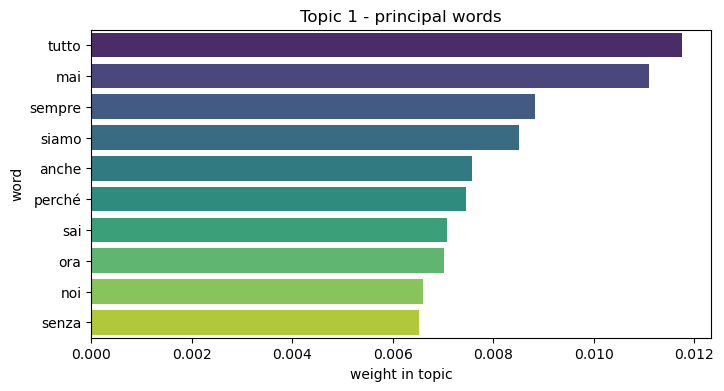

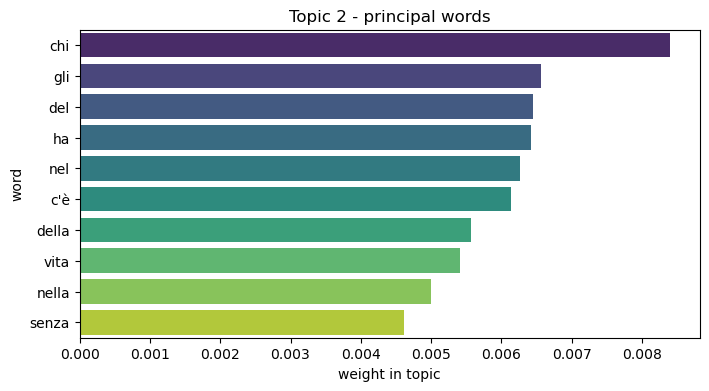

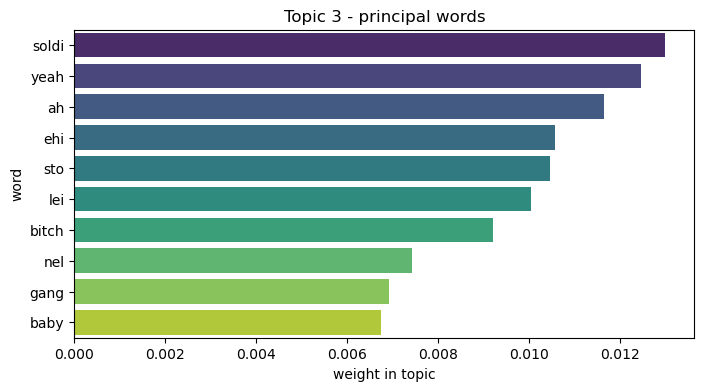

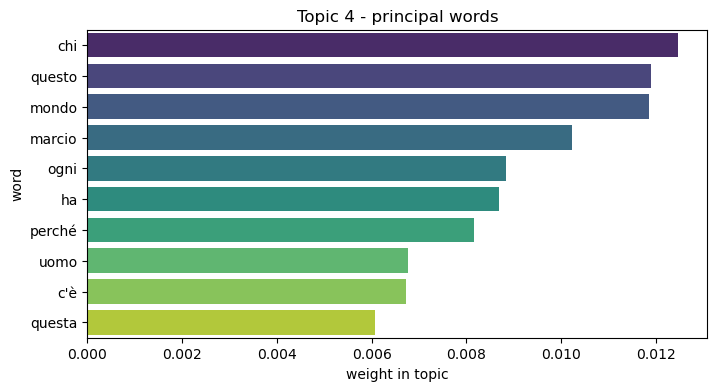

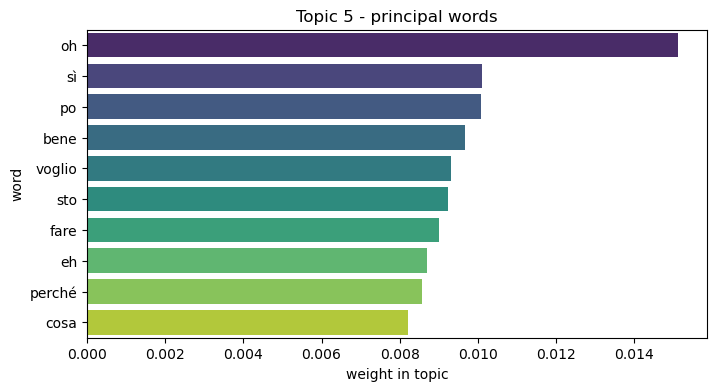

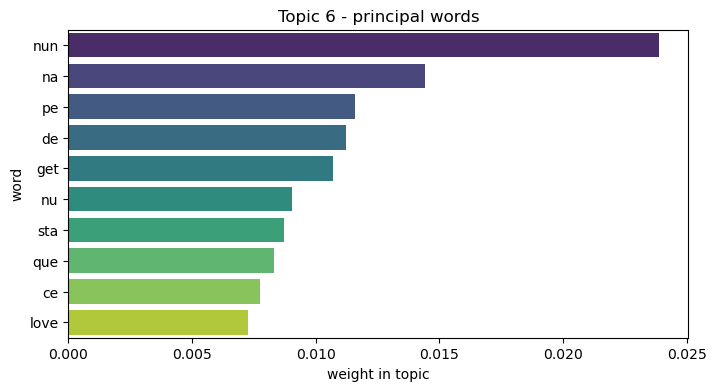

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

num_words_to_show = 10  

for i, topic in lda_model.show_topics(num_topics=num_topics, num_words=num_words_to_show, formatted=False):
    words = [word for word, weight in topic]
    weights = [weight for word, weight in topic]
    
    plt.figure(figsize=(8,4))
    sns.barplot(x=weights, y=words, palette="viridis")
    plt.title(f"Topic {i} - principal words")
    plt.xlabel("weight in topic")
    plt.ylabel("word")
    plt.show()


In [ ]:
# topic mapping
topic_labels = {
    0: "Rap_Street",
    1: "life_emotions",
    2: "Questions_Reflection",
    3: "Party_Trap",
    4: "Critique_Society",
    5: "Feelings_Love",
    6: "Rap_Neapolitan"
}

# add the column with names
df['lyric_topic_label'] = df['lyric_category'].map(topic_labels)

# check distribution
df['lyric_topic_label'].value_counts()


lyric_topic_label
Rap_Street              3237
life_emotions           2832
Questions_Reflection    1444
Critique_Society        1115
Feelings_Love            892
Party_Trap               687
Rap_Neapolitan           554
Name: count, dtype: int64

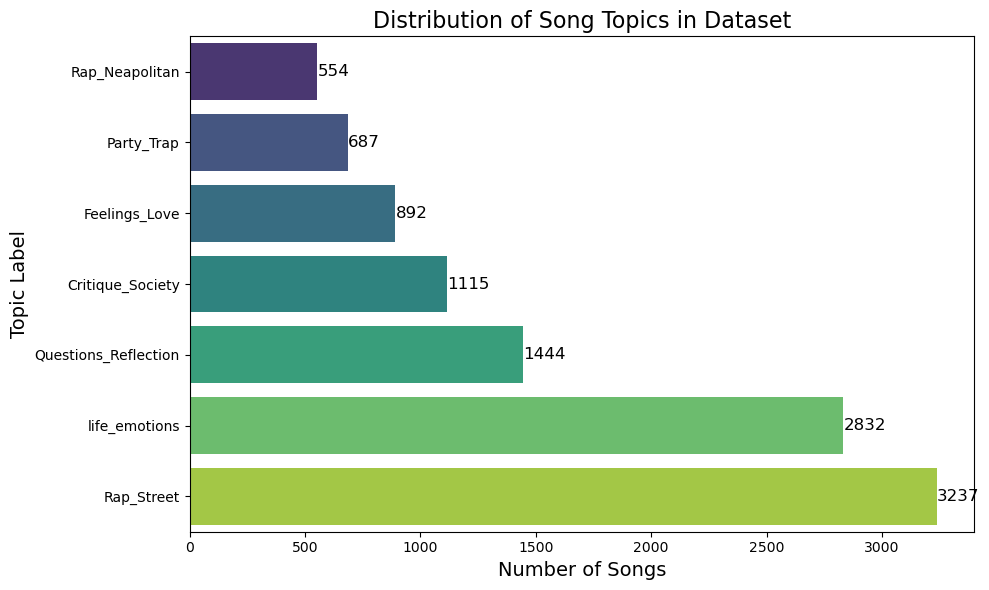

In [42]:
# calculate topic counts
topic_counts = df['lyric_topic_label'].value_counts().sort_values(ascending=True)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=topic_counts.values, y=topic_counts.index, palette="viridis")

plt.title("Distribution of Song Topics in Dataset", fontsize=16)
plt.xlabel("Number of Songs", fontsize=14)
plt.ylabel("Topic Label", fontsize=14)

# Mostra il numero esatto di canzoni su ciascuna barra
for i, v in enumerate(topic_counts.values):
    plt.text(v + 1, i, str(v), color='black', va='center', fontsize=12)

plt.tight_layout()
plt.show()

In [41]:
df.columns

Index(['id', 'id_artist', 'title', 'featured_artists', 'primary_artist',
       'album', 'swear_IT', 'swear_EN', 'year', 'month', 'day', 'n_sentences',
       'n_tokens', 'char_per_tok', 'avg_token_per_clause', 'bpm', 'rolloff',
       'flux', 'rms', 'flatness', 'spectral_complexity', 'pitch', 'album_name',
       'album_release_date', 'album_type', 'disc_number', 'track_number',
       'duration_ms', 'explicit', 'popularity', 'id_album', 'streams@1month',
       'swear_IT_words_clean', 'swear_EN_words_clean', 'lyrics_clean',
       'season', 'language_group', 'track_lyrics_clean', 'lyric_category',
       'lyric_topic_label'],
      dtype='object')

In [43]:
#Category based on audio features
melody_features = ['bpm', 'rolloff', 'flux', 'rms', 'flatness', 'spectral_complexity', 'pitch']
X_melody = df[melody_features].dropna()  # additional check (we dont have nan)

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_melody)


In [45]:
from sklearn.cluster import KMeans

#chose a number of cluster, e.g. 5
num_clusters = 5

kmeans = KMeans(n_clusters=num_clusters, random_state=42)
df['melody_category'] = kmeans.fit_predict(X_scaled)


In [ ]:
# count how many songs belong to each cluster
cluster_counts = df['melody_category'].value_counts().sort_index()
print(cluster_counts)


melody_category
0    2233
1     259
2    3004
3    2778
4    2487
Name: count, dtype: int64


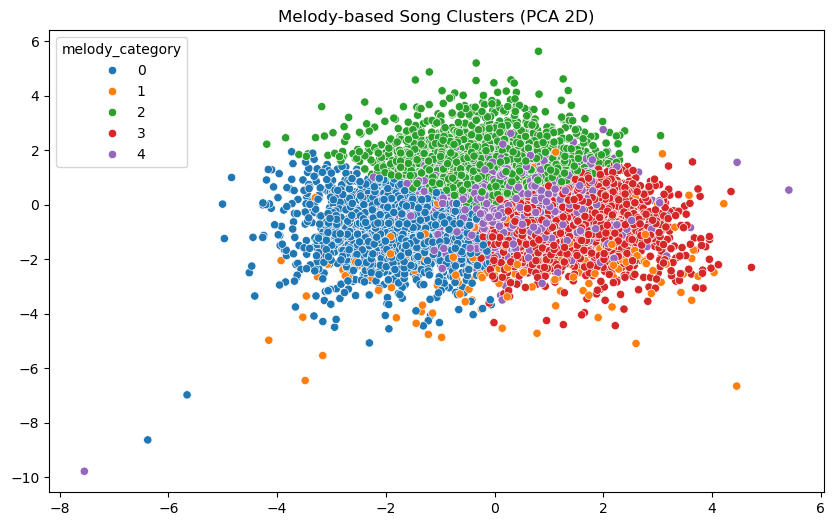

In [47]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['melody_category'], palette='tab10')
plt.title("Melody-based Song Clusters (PCA 2D)")
plt.show()


In [46]:
# distribuzione dei cluster
df['melody_category'].value_counts()

# media delle feature per cluster
df.groupby('melody_category')[melody_features].mean()


,bpm,rolloff,flux,rms,flatness,spectral_complexity,pitch
melody_category,,,,,,,
0,110.720067,1398.658260,1.155830,0.149865,0.882826,18.855234,2104.488858
1,109.718301,1811.764127,1.239733,0.185670,0.271990,25.000570,2198.879726
2,106.562300,1454.235127,1.369366,0.242833,0.881133,24.654502,2614.751772
3,101.661148,2117.912322,1.254743,0.242342,0.848616,35.055476,2035.410362
4,141.455883,1432.401126,1.220591,0.254926,0.888629,30.394379,2200.571496


In [50]:
# mappatura cluster -> descrizione melodica
melody_category_labels = {
    0: "Mid-tempo_Soft",
    1: "Mid-tempo_MelodicRich",
    2: "Slow_Powerful",
    3: "Slow_Experimental_Complex",
    4: "Fast_Energetic_Party"
}

# add column
df['melody_category_label'] = df['melody_category'].map(melody_category_labels)

# check distribution
df['melody_category_label'].value_counts()


melody_category_label
Slow_Powerful                3004
Slow_Experimental_Complex    2778
Fast_Energetic_Party         2487
Mid-tempo_Soft               2233
Mid-tempo_MelodicRich         259
Name: count, dtype: int64

In [51]:
df.columns

Index(['id', 'id_artist', 'title', 'featured_artists', 'primary_artist',
       'album', 'swear_IT', 'swear_EN', 'year', 'month', 'day', 'n_sentences',
       'n_tokens', 'char_per_tok', 'avg_token_per_clause', 'bpm', 'rolloff',
       'flux', 'rms', 'flatness', 'spectral_complexity', 'pitch', 'album_name',
       'album_release_date', 'album_type', 'disc_number', 'track_number',
       'duration_ms', 'explicit', 'popularity', 'id_album', 'streams@1month',
       'swear_IT_words_clean', 'swear_EN_words_clean', 'lyrics_clean',
       'season', 'language_group', 'track_lyrics_clean', 'lyric_category',
       'lyric_topic_label', 'melody_category', 'melody_category_label'],
      dtype='object')

In [52]:
df_export = df.copy()

In [ ]:
#we should drop all columns that we wont use:
# 'track_lyrics_clean', 'lyrics_clean', 'lyric_category'
# 'bpm', 'rolloff', 'flux', 'rms', 'flatness', 'spectral_complexity', 'pitch', 'melody_category'

# columns_to_drop = ['lyrics_clean', 'lyric_category']

# # 'axis=1' because they are columns
# df_export = df_export.drop(columns=columns_to_drop, axis=1)

In [53]:
# index=False avoid writing the index column to the CSV.”
output_filename = 'df_withSongCategory.csv'
df_export.to_csv(output_filename, index=False)

# print(f"columns '{columns_to_drop}' successfully removed from the copy.")
print(f"file clean and copied in: {output_filename}")

file clean and copied in: df_withSongCategory.csv
